Shape of dataset: (11, 8)
  PatientID  Age  Gender       ArrivalTime TriageLevel  WaitingTimeMinutes  \
0     P1001   52  Female   21/02/2026 3:00     Level 5               204.0   
1     P1002   15  Female   24/02/2026 8:15     Level 3                58.0   
2     P1003   72  Female   08/02/2026 4:55     Level 5                 NaN   
3     P1004   61  Female  04/02/2026 21:55     Level 3                66.0   
4     P1005   21   Other   18/02/2026 2:45     Level 1                29.0   

  DoctorAssigned AdmissionStatus  
0       Dr. Khan      Discharged  
1       Dr. Sara     Transferred  
2       Dr. Noor      Discharged  
3       Dr. Noor      Discharged  
4        Dr. Ali        Admitted  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PatientID           11 non-null     object 
 1   Age                 11 non-null     int64

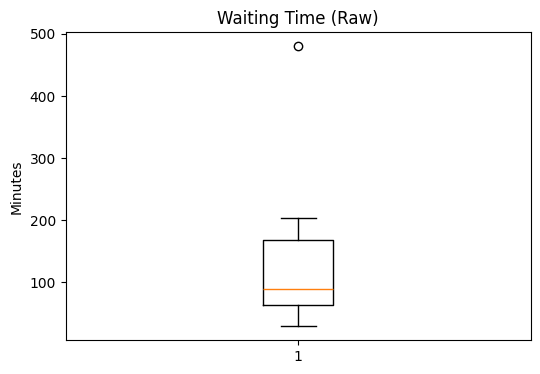

After Cleaning Shape: (10, 8)
PatientID             0
Age                   0
Gender                0
ArrivalTime           0
TriageLevel           0
WaitingTimeMinutes    0
DoctorAssigned        0
AdmissionStatus       0
dtype: int64
                 Frequency  Percentage
AdmissionStatus                       
Discharged               7        70.0
Admitted                 2        20.0
Transferred              1        10.0


/tmp/ipykernel_3616/3161478567.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df["Age"].fillna(clean_df["Age"].median(), inplace=True)
/tmp/ipykernel_3616/3161478567.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

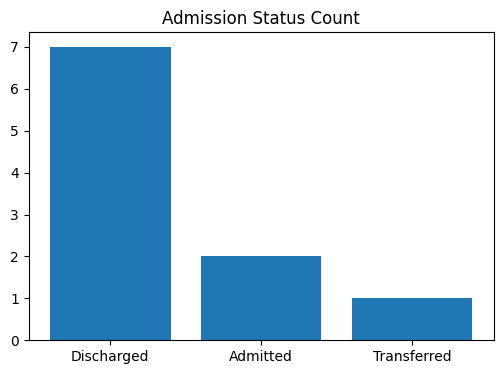

count     10.000000
mean     136.600000
std      131.831711
min       29.000000
25%       63.750000
50%       89.000000
75%      156.000000
max      480.000000
Name: WaitingTimeMinutes, dtype: float64


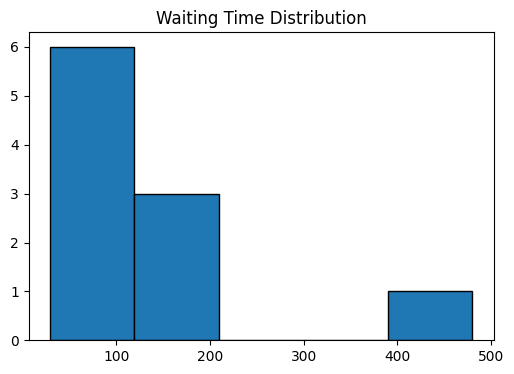

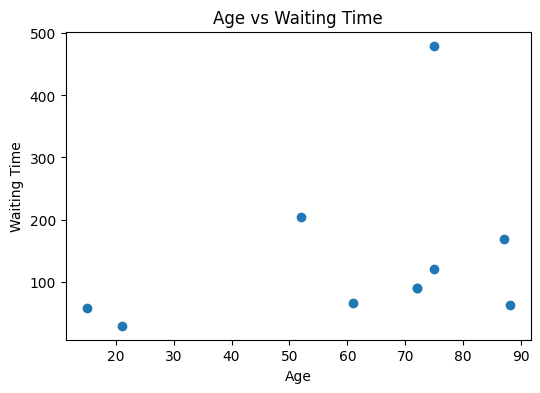

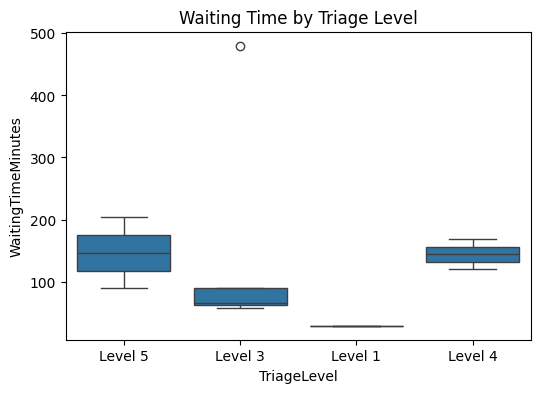

AdmissionStatus  Admitted  Discharged  Transferred
TriageLevel                                       
Level 1                 1           0            0
Level 3                 0           4            1
Level 4                 1           1            0
Level 5                 0           2            0


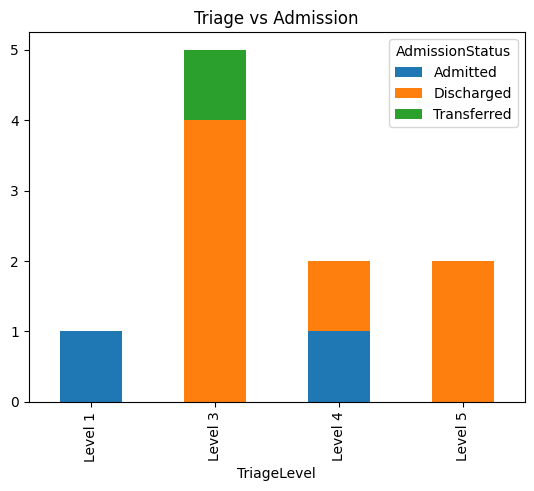

                        Age  WaitingTimeMinutes
Age                 1.00000             0.32024
WaitingTimeMinutes  0.32024             1.00000


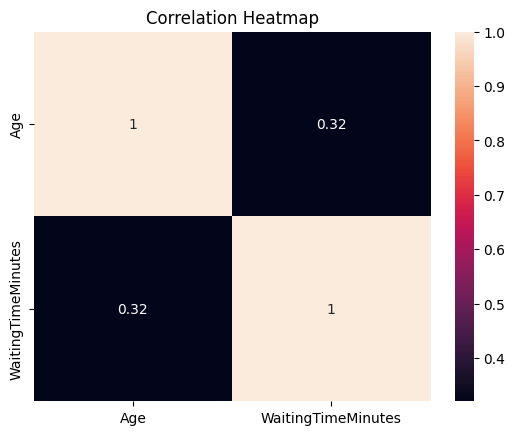

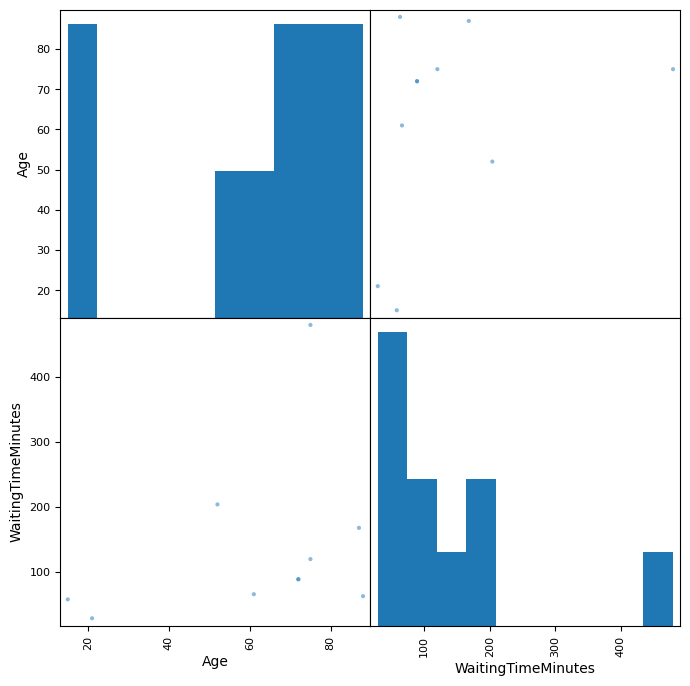

EDA Findings:
1. Dataset cleaned and duplicates removed.
2. Waiting time varies significantly across triage levels.
3. Some invalid ages were corrected.
4. Higher triage urgency may relate to shorter waiting times.
5. Weak correlation between age and waiting time.


In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
# NEW DATASET (Hospital Data)
data = {
    "PatientID": ["P1001", "P1002", "P1003", "P1004", "P1005", "P1006", "P1007", "P1008", "P1009", "P1010"],
    "Age": [52, 15, 72, 61, 21, -3, 87, 75, 75, 88],
    "Gender": ["Female", "Female", "Female", "Female", "Other", "Female", "Male", "Male", "Male", "Male"],
    "ArrivalTime": [
        "21/02/2026 3:00", "24/02/2026 8:15", "08/02/2026 4:55",
        "04/02/2026 21:55", "18/02/2026 2:45", "14/02/2026 1:00",
        "03/02/2026 6:15", "17/02/2026 19:00", "18/02/2026 6:55",
        "21/02/2026 22:40"
    ],
    "TriageLevel": ["Level 5", "Level 3", "Level 5", "Level 3", "Level 1", "Level 3", "Level 4", "Level 4", "Level 3", "Level 3"],
    "WaitingTimeMinutes": [204, 58, np.nan, 66, 29, 89, 168, 120, 480, 63],
    "DoctorAssigned": ["Dr. Khan", "Dr. Sara", "Dr. Noor", "Dr. Noor", "Dr. Ali", "Dr. Sara", "Dr. Khan", "Dr. Noor", "Dr. Ali", "Dr. Ahmed"],
    "AdmissionStatus": ["Discharged", "Transferred", "Discharged", "Discharged", "Admitted", "Discharged", "Discharged", "Admitted", "Discharged", "Discharged"]
}
raw_df = pd.DataFrame(data)
raw_df = pd.concat([raw_df, raw_df.iloc[[2]]], ignore_index=True)

# BASIC INFO
print("Shape of dataset:", raw_df.shape)
print(raw_df.head())
print(raw_df.info())

# VARIABLE TYPES
variable_types = pd.DataFrame({
    "Variable": raw_df.columns,
    "Suggested Type": ["ID", "Numerical", "Categorical", "Datetime", "Categorical", "Numerical", "Categorical", "Categorical"]
})
print(variable_types)

# DATA QUALITY CHECKS
print("Missing values:\n", raw_df.isnull().sum())
print("Duplicate rows:", raw_df.duplicated().sum())
print("Unique Gender:", raw_df["Gender"].unique())
print("Unique AdmissionStatus:", raw_df["AdmissionStatus"].unique())
invalid_age = raw_df[raw_df["Age"] < 0]
invalid_wait = raw_df[raw_df["WaitingTimeMinutes"] < 0]

print("Invalid Age:\n", invalid_age)
print("Invalid Waiting Time:\n", invalid_wait)

# RAW VISUALIZATION
plt.figure(figsize=(6, 4))
plt.boxplot(raw_df["WaitingTimeMinutes"].dropna())
plt.title("Waiting Time (Raw)")
plt.ylabel("Minutes")
plt.show()

# DATA CLEANING
clean_df = raw_df.copy()

# Fix text inconsistencies
clean_df["AdmissionStatus"] = clean_df["AdmissionStatus"].str.strip().str.title()
clean_df["Gender"] = clean_df["Gender"].str.strip().str.title()

clean_df.loc[clean_df["Age"] < 0, "Age"] = np.nan

clean_df["Age"].fillna(clean_df["Age"].median(), inplace=True)
clean_df["WaitingTimeMinutes"].fillna(clean_df["WaitingTimeMinutes"].median(), inplace=True)

clean_df["ArrivalTime"] = pd.to_datetime(clean_df["ArrivalTime"], dayfirst=True)

# REMOVE DUPLICATES
clean_df = clean_df.drop_duplicates()

# CLEANED DATA CHECK
print("After Cleaning Shape:", clean_df.shape)
print(clean_df.isnull().sum())

# STATUS ANALYSIS
status_counts = clean_df["AdmissionStatus"].value_counts()
status_percent = clean_df["AdmissionStatus"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Frequency": status_counts,
    "Percentage": status_percent.round(2)
})
print(summary)

# BAR CHART
plt.figure(figsize=(6, 4))
plt.bar(status_counts.index, status_counts.values)
plt.title("Admission Status Count")
plt.show()

# WAITING TIME STATS
print(clean_df["WaitingTimeMinutes"].describe())

# HISTOGRAM
plt.figure(figsize=(6, 4))
plt.hist(clean_df["WaitingTimeMinutes"], bins=5, edgecolor="black")
plt.title("Waiting Time Distribution")
plt.show()

# SCATTER PLOT
plt.figure(figsize=(6, 4))
plt.scatter(clean_df["Age"], clean_df["WaitingTimeMinutes"])
plt.xlabel("Age")
plt.ylabel("Waiting Time")
plt.title("Age vs Waiting Time")
plt.show()

# BOXPLOT BY TRIAGE LEVEL
plt.figure(figsize=(6, 4))
sns.boxplot(data=clean_df, x="TriageLevel", y="WaitingTimeMinutes")
plt.title("Waiting Time by Triage Level")
plt.show()

# CROSSTAB
crosstab = pd.crosstab(clean_df["TriageLevel"], clean_df["AdmissionStatus"])
print(crosstab)
crosstab.plot(kind="bar", stacked=True)
plt.title("Triage vs Admission")
plt.show()

# CORRELATION
numeric_cols = ["Age", "WaitingTimeMinutes"]
corr = clean_df[numeric_cols].corr()
print(corr)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# SCATTER MATRIX
scatter_matrix(clean_df[numeric_cols], figsize=(8, 8))
plt.show()

# FINAL INSIGHTS
print("EDA Findings:")
print("1. Dataset cleaned and duplicates removed.")
print("2. Waiting time varies significantly across triage levels.")
print("3. Some invalid ages were corrected.")
print("4. Higher triage urgency may relate to shorter waiting times.")
print("5. Weak correlation between age and waiting time.")



Shape of dataset: (11, 8)
  OrderID CustomerRegion ProductCategory  OrderValue  DeliveryDays  \
0   O5001           East         Fashion      215.44           6.0   
1   O5002          North         Fashion      269.86           2.0   
2   O5003           East     Electronics      267.41           7.0   
3   O5004           West            Home      103.40           2.0   
4   O5005           East          Beauty       32.82          11.0   

   DiscountPercent Returned PaymentMethod  
0               40       No        Wallet  
1               25      Yes          Card  
2               50       No          Card  
3              110      Yes           COD  
4               10       No        Wallet  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          11 non-null     object 
 1   CustomerRegion   11 non-null     object 
 2 

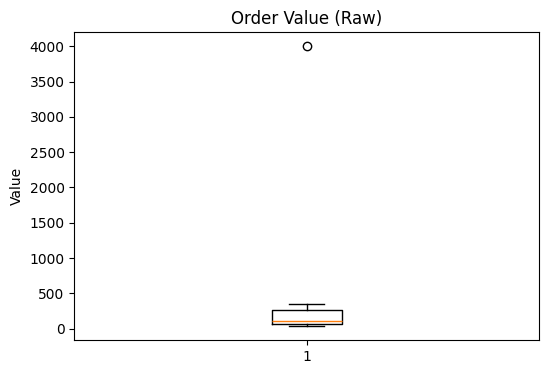

After Cleaning Shape: (10, 8)
OrderID            0
CustomerRegion     0
ProductCategory    0
OrderValue         0
DeliveryDays       0
DiscountPercent    0
Returned           0
PaymentMethod      0
dtype: int64
          Frequency  Percentage
Returned                       
No                7        70.0
Yes               3        30.0


/tmp/ipykernel_3616/1698295501.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df["DeliveryDays"].fillna(clean_df["DeliveryDays"].median(), inplace=True)


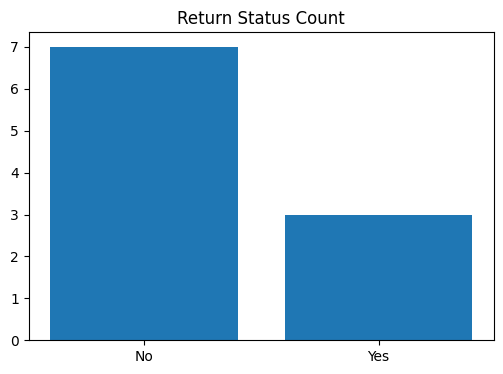

count      10.000000
mean      541.989000
std      1220.287158
min        32.820000
25%        61.722500
50%       159.420000
75%       269.247500
max      3999.990000
Name: OrderValue, dtype: float64


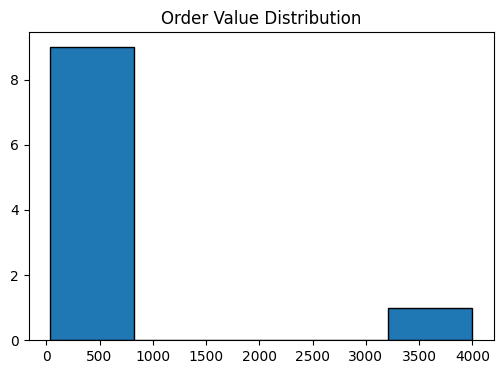

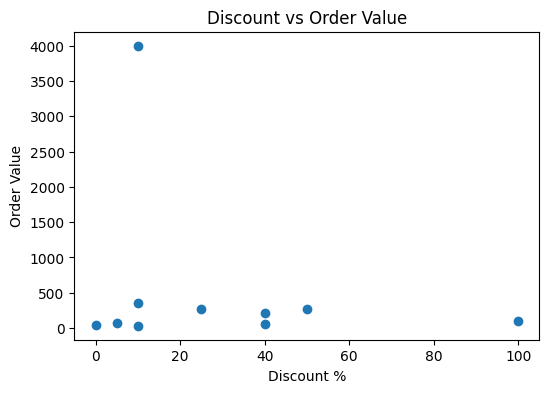

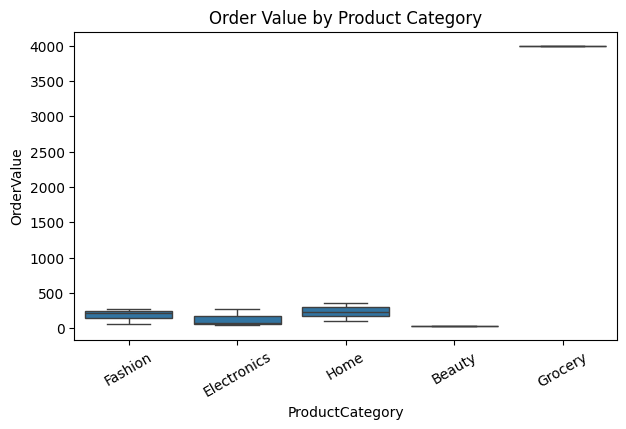

Returned         No  Yes
ProductCategory         
Beauty            1    0
Electronics       3    0
Fashion           2    1
Grocery           1    0
Home              0    2


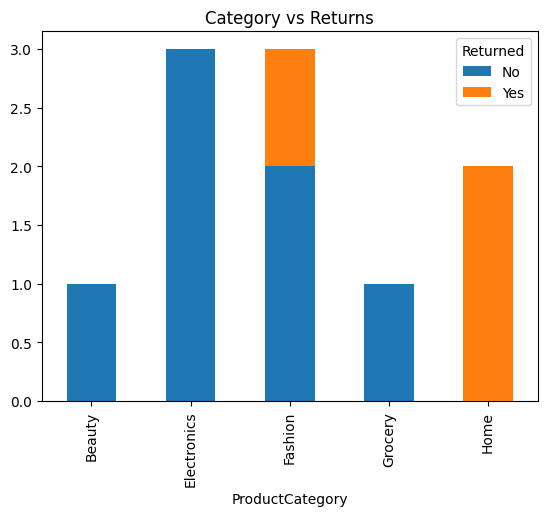

                 OrderValue  DeliveryDays  DiscountPercent
OrderValue             1.00          0.42            -0.22
DeliveryDays           0.42          1.00            -0.43
DiscountPercent       -0.22         -0.43             1.00


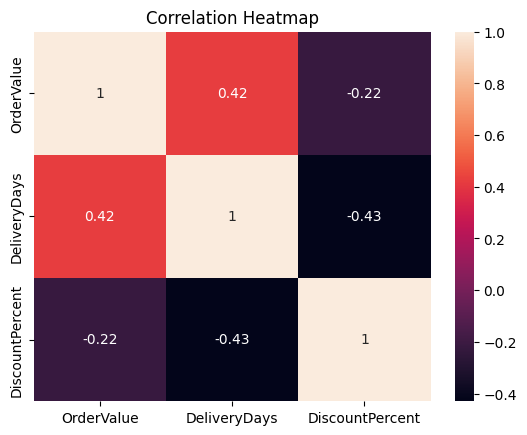

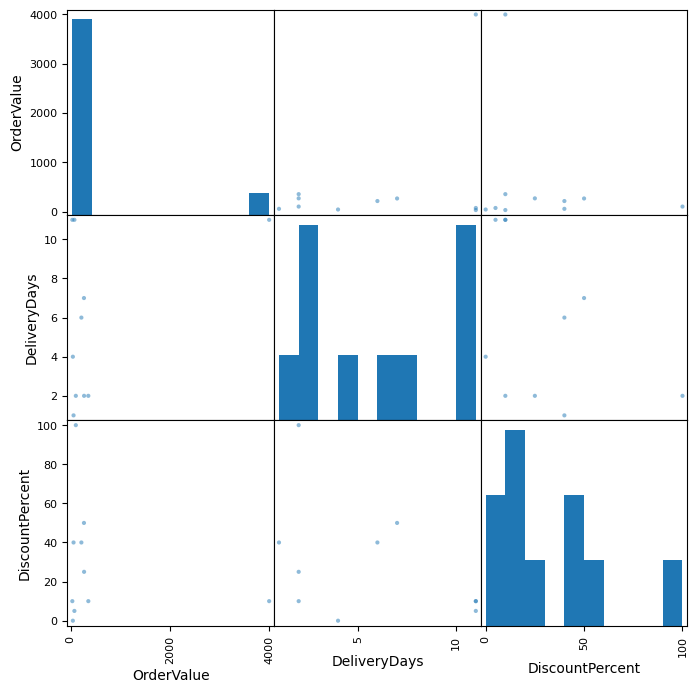

EDA Findings:
1. Dataset cleaned and duplicates removed.
2. Some invalid discount values (>100%) were corrected.
3. Most orders are not returned.
4. High discounts do not always mean higher order value.
5. Certain product categories may have higher return rates.


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# -------------------------------
# NEW DATASET (E-commerce)
# -------------------------------
data = {
    "OrderID": ["O5001", "O5002", "O5003", "O5004", "O5005", "O5006", "O5007", "O5008", "O5009", "O5010"],
    "CustomerRegion": ["East", "North", "East", "West", "East", "Central", "South", "West", "South", "Central"],
    "ProductCategory": ["Fashion", "Fashion", "Electronics", "Home", "Beauty", "Home", "Electronics", "Fashion", "Electronics", "Grocery"],
    "OrderValue": [215.44, 269.86, 267.41, 103.4, 32.82, 355.28, 43.68, 57.44, 74.57, 3999.99],
    "DeliveryDays": [6, 2, 7, 2, 11, 2, np.nan, 1, 11, 11],
    "DiscountPercent": [40, 25, 50, 110, 10, 10, 0, 40, 5, 10],
    "Returned": ["No", "Yes", "No", "Yes", "No", "yes", "No", "No", "No", "No"],
    "PaymentMethod": ["Wallet", "Card", "Card", "COD", "Wallet", "Bank Transfer", "Wallet", "Card", "Card", "Wallet"]
}
raw_df = pd.DataFrame(data)
raw_df = pd.concat([raw_df, raw_df.iloc[[3]]], ignore_index=True)

# Basic info
print("Shape of dataset:", raw_df.shape)
print(raw_df.head())
print(raw_df.info())

# Variable types
variable_types = pd.DataFrame({
    "Variable": raw_df.columns,
    "Suggested Type": ["ID", "Categorical", "Categorical", "Numerical", "Numerical", "Numerical", "Categorical", "Categorical"]
})
print(variable_types)

# Data quality checks
print("Missing values:\n", raw_df.isnull().sum())
print("Duplicate rows:", raw_df.duplicated().sum())
print("Unique ProductCategory:", raw_df["ProductCategory"].unique())
print("Unique Returned:", raw_df["Returned"].unique())

# Invalid values
invalid_discount = raw_df[(raw_df["DiscountPercent"] < 0) | (raw_df["DiscountPercent"] > 100)]
invalid_value = raw_df[raw_df["OrderValue"] < 0]
print("Invalid Discount:\n", invalid_discount)
print("Invalid Order Value:\n", invalid_value)

# Raw visualization
plt.figure(figsize=(6, 4))
plt.boxplot(raw_df["OrderValue"].dropna())
plt.title("Order Value (Raw)")
plt.ylabel("Value")
plt.show()

# Data cleaning
clean_df = raw_df.copy()

# Fix text inconsistencies
clean_df["Returned"] = clean_df["Returned"].str.strip().str.title()
clean_df.loc[clean_df["DiscountPercent"] > 100, "DiscountPercent"] = 100
clean_df["DeliveryDays"].fillna(clean_df["DeliveryDays"].median(), inplace=True)
clean_df = clean_df.drop_duplicates()
print("After Cleaning Shape:", clean_df.shape)
print(clean_df.isnull().sum())
return_counts = clean_df["Returned"].value_counts()
return_percent = clean_df["Returned"].value_counts(normalize=True) * 100
summary = pd.DataFrame({
    "Frequency": return_counts,
    "Percentage": return_percent.round(2)
})
print(summary)

# Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(return_counts.index, return_counts.values)
plt.title("Return Status Count")
plt.show()

# Order Value Stats
print(clean_df["OrderValue"].describe())

# Histogram
plt.figure(figsize=(6, 4))
plt.hist(clean_df["OrderValue"], bins=5, edgecolor="black")
plt.title("Order Value Distribution")
plt.show()

# Scatter Plot
plt.figure(figsize=(6, 4))
plt.scatter(clean_df["DiscountPercent"], clean_df["OrderValue"])
plt.xlabel("Discount %")
plt.ylabel("Order Value")
plt.title("Discount vs Order Value")
plt.show()

# Boxplot by Category
plt.figure(figsize=(7, 4))
sns.boxplot(data=clean_df, x="ProductCategory", y="OrderValue")
plt.title("Order Value by Product Category")
plt.xticks(rotation=30)
plt.show()

# Crosstab
crosstab = pd.crosstab(clean_df["ProductCategory"], clean_df["Returned"])
print(crosstab)
crosstab.plot(kind="bar", stacked=True)
plt.title("Category vs Returns")
plt.show()

# Correlation
numeric_cols = ["OrderValue", "DeliveryDays", "DiscountPercent"]
corr = clean_df[numeric_cols].corr().round(2)
print(corr)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Scatter Matrix
scatter_matrix(clean_df[numeric_cols], figsize=(8, 8))
plt.show()

#Insights
print("EDA Findings:")
print("1. Dataset cleaned and duplicates removed.")
print("2. Some invalid discount values (>100%) were corrected.")
print("3. Most orders are not returned.")
print("4. High discounts do not always mean higher order value.")
print("5. Certain product categories may have higher return rates.")


Shape of dataset: (11, 8)
  StudentID Department  AttendancePercent  LMSLoginsPerWeek  \
0     S2001         IT               85.9              10.0   
1     S2002         IT               86.1              11.0   
2     S2003         IT              104.0               9.0   
3     S2004         AI               84.5               9.0   
4     S2005         IT               62.8               9.0   

   AssignmentAverage  FamilyIncome ScholarshipStatus DropoutRisk  
0               56.9        122686                No      Medium  
1               48.2         23996                No      Medium  
2               58.8        105651                No      Medium  
3               67.4        111267                No         Low  
4               61.6       2500000                No      Medium  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  ---

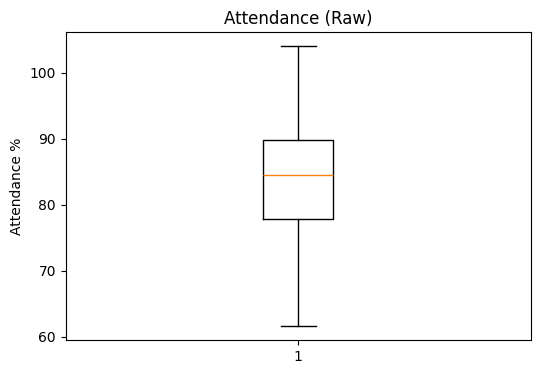

After Cleaning Shape: (10, 8)
StudentID            0
Department           0
AttendancePercent    0
LMSLoginsPerWeek     0
AssignmentAverage    0
FamilyIncome         0
ScholarshipStatus    0
DropoutRisk          0
dtype: int64
             Frequency  Percentage
DropoutRisk                       
Medium               5        50.0
Low                  3        30.0
High                 2        20.0


/tmp/ipykernel_3616/1754300878.py:77: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df["LMSLoginsPerWeek"].fillna(clean_df["LMSLoginsPerWeek"].median(), inplace=True)


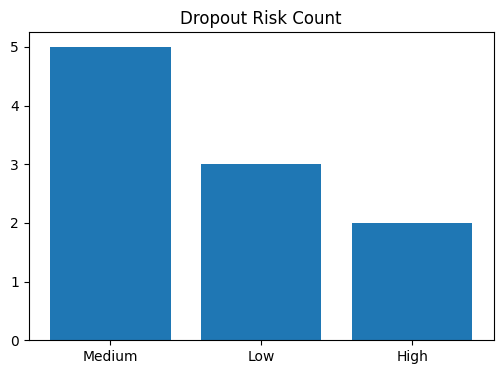

count    10.000000
mean     58.900000
std      10.586364
min      45.400000
25%      50.375000
50%      58.200000
75%      65.500000
max      79.400000
Name: AssignmentAverage, dtype: float64


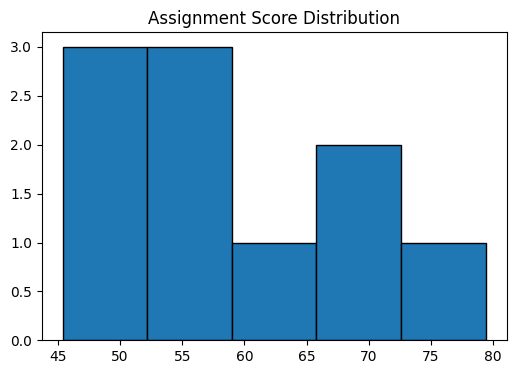

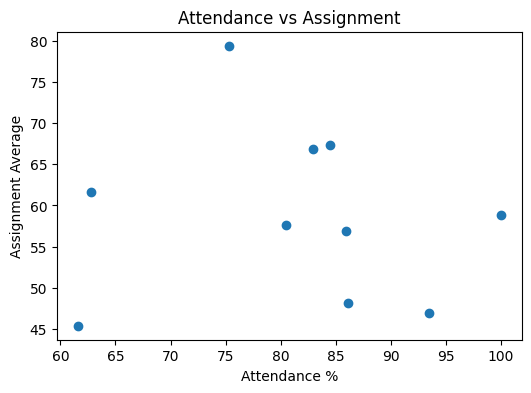

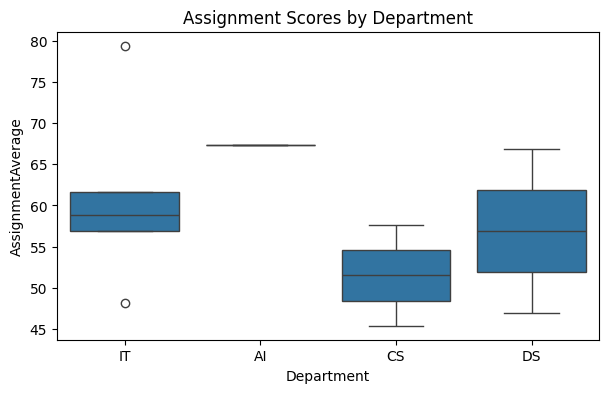

DropoutRisk        High  Low  Medium
ScholarshipStatus                   
No                    1    2       4
Partial               1    0       1
Yes                   0    1       0


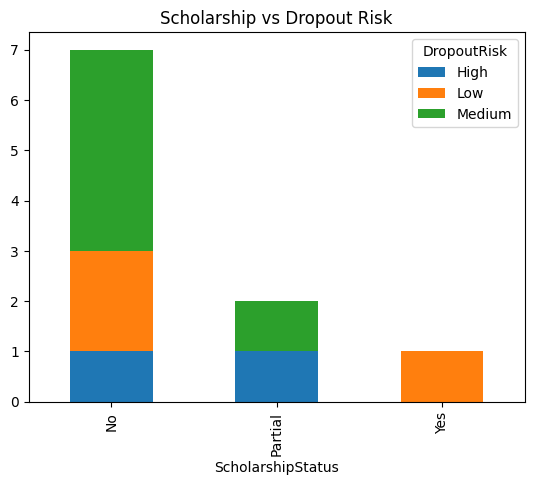

                   AttendancePercent  LMSLoginsPerWeek  AssignmentAverage  \
AttendancePercent               1.00             -0.04              -0.06   
LMSLoginsPerWeek               -0.04              1.00               0.21   
AssignmentAverage              -0.06              0.21               1.00   
FamilyIncome                   -0.53              0.01               0.11   

                   FamilyIncome  
AttendancePercent         -0.53  
LMSLoginsPerWeek           0.01  
AssignmentAverage          0.11  
FamilyIncome               1.00  


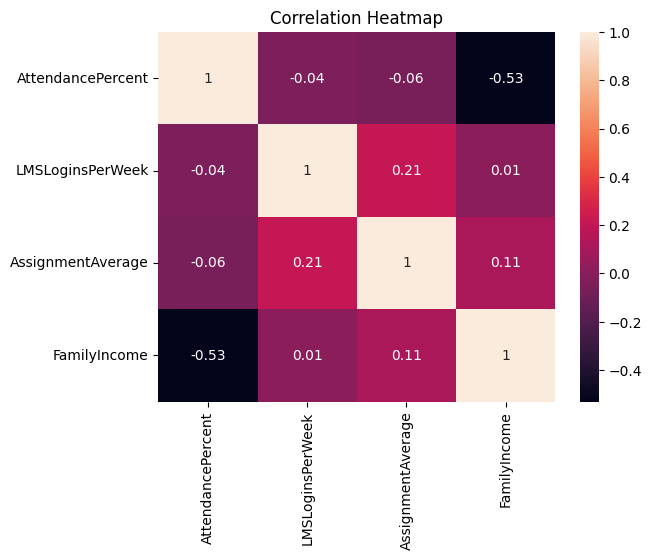

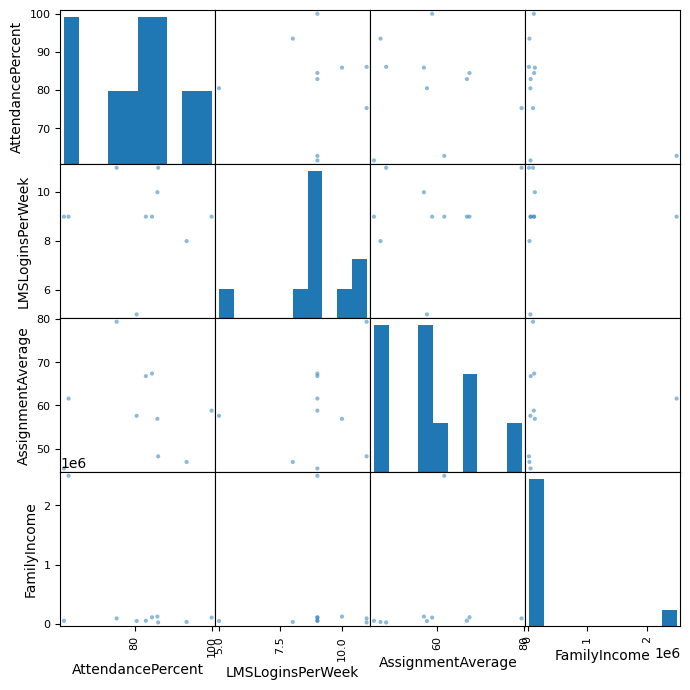

EDA Findings:
1. Dataset cleaned and duplicates removed.
2. Invalid attendance (>100%) was corrected.
3. Students with lower attendance tend to have higher dropout risk.
4. Assignment performance is positively related to attendance.
5. Scholarship students may have different dropout patterns.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# -------------------------------
# NEW DATASET (Dropout Risk)
# -------------------------------
data = {
    "StudentID": ["S2001","S2002","S2003","S2004","S2005","S2006","S2007","S2008","S2009","S2010"],
    "Department": ["IT","IT","IT","AI","IT","CS","DS","DS","CS","IT"],
    "AttendancePercent": [85.9,86.1,104,84.5,62.8,80.5,93.5,82.9,61.6,75.3],
    "LMSLoginsPerWeek": [10,11,9,9,9,5,8,9,np.nan,11],
    "AssignmentAverage": [56.9,48.2,58.8,67.4,61.6,57.6,46.9,66.8,45.4,79.4],
    "FamilyIncome": [122686,23996,105651,111267,2500000,47765,32593,53199,50543,91933],
    "ScholarshipStatus": ["No","No","No","No","No","Partial","Partial","yes","No","No"],
    "DropoutRisk": ["Medium","Medium","Medium","Low","Medium","High","Medium","Low","High","Low"]
}

raw_df = pd.DataFrame(data)

# Add duplicate row (same logic)
raw_df = pd.concat([raw_df, raw_df.iloc[[2]]], ignore_index=True)

print("Shape of dataset:", raw_df.shape)
print(raw_df.head())
print(raw_df.info())

# -------------------------------
# VARIABLE TYPES
# -------------------------------
variable_types = pd.DataFrame({
    "Variable": raw_df.columns,
    "Suggested Type": ["ID","Categorical","Numerical","Numerical","Numerical","Numerical","Categorical","Categorical"]
})
print(variable_types)

# -------------------------------
# DATA QUALITY CHECKS
# -------------------------------
print("Missing values:\n", raw_df.isnull().sum())
print("Duplicate rows:", raw_df.duplicated().sum())

print("Unique ScholarshipStatus:", raw_df["ScholarshipStatus"].unique())
print("Unique DropoutRisk:", raw_df["DropoutRisk"].unique())

# Invalid values
invalid_attendance = raw_df[(raw_df["AttendancePercent"] < 0) | (raw_df["AttendancePercent"] > 100)]
invalid_income = raw_df[raw_df["FamilyIncome"] < 0]

print("Invalid Attendance:\n", invalid_attendance)
print("Invalid Income:\n", invalid_income)

# -------------------------------
# VISUALIZATION (RAW)
# -------------------------------
plt.figure(figsize=(6, 4))
plt.boxplot(raw_df["AttendancePercent"].dropna())
plt.title("Attendance (Raw)")
plt.ylabel("Attendance %")
plt.show()

# -------------------------------
# DATA CLEANING
# -------------------------------
clean_df = raw_df.copy()

# Fix text formatting
clean_df["ScholarshipStatus"] = clean_df["ScholarshipStatus"].str.strip().str.title()
clean_df["DropoutRisk"] = clean_df["DropoutRisk"].str.strip().str.title()

# Fix invalid attendance (>100)
clean_df.loc[clean_df["AttendancePercent"] > 100, "AttendancePercent"] = 100

# Fill missing LMS logins
clean_df["LMSLoginsPerWeek"].fillna(clean_df["LMSLoginsPerWeek"].median(), inplace=True)

# Remove duplicates
clean_df = clean_df.drop_duplicates()

print("After Cleaning Shape:", clean_df.shape)
print(clean_df.isnull().sum())

# -------------------------------
# EDA
# -------------------------------

# Dropout Risk Summary
risk_counts = clean_df["DropoutRisk"].value_counts()
risk_percent = clean_df["DropoutRisk"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Frequency": risk_counts,
    "Percentage": risk_percent.round(2)
})
print(summary)

# Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Dropout Risk Count")
plt.show()

# Assignment Score Stats
print(clean_df["AssignmentAverage"].describe())

# Histogram
plt.figure(figsize=(6, 4))
plt.hist(clean_df["AssignmentAverage"], bins=5, edgecolor="black")
plt.title("Assignment Score Distribution")
plt.show()

# Scatter Plot
plt.figure(figsize=(6, 4))
plt.scatter(clean_df["AttendancePercent"], clean_df["AssignmentAverage"])
plt.xlabel("Attendance %")
plt.ylabel("Assignment Average")
plt.title("Attendance vs Assignment")
plt.show()

# Boxplot by Department
plt.figure(figsize=(7, 4))
sns.boxplot(data=clean_df, x="Department", y="AssignmentAverage")
plt.title("Assignment Scores by Department")
plt.show()

# Crosstab
crosstab = pd.crosstab(clean_df["ScholarshipStatus"], clean_df["DropoutRisk"])
print(crosstab)

crosstab.plot(kind="bar", stacked=True)
plt.title("Scholarship vs Dropout Risk")
plt.show()

# Correlation
numeric_cols = ["AttendancePercent","LMSLoginsPerWeek","AssignmentAverage","FamilyIncome"]
corr = clean_df[numeric_cols].corr().round(2)

print(corr)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Scatter Matrix
scatter_matrix(clean_df[numeric_cols], figsize=(8, 8))
plt.show()

# -------------------------------
# INSIGHTS
# -------------------------------
print("EDA Findings:")
print("1. Dataset cleaned and duplicates removed.")
print("2. Invalid attendance (>100%) was corrected.")
print("3. Students with lower attendance tend to have higher dropout risk.")
print("4. Assignment performance is positively related to attendance.")
print("5. Scholarship students may have different dropout patterns.")

